In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


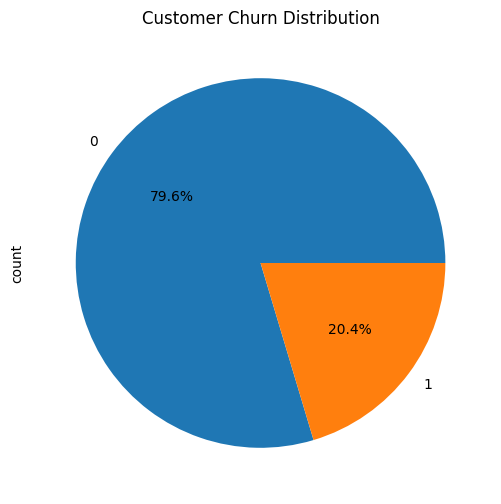

In [8]:
plt.figure(figsize=(6,6))

df['Exited'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Customer Churn Distribution")

plt.show()

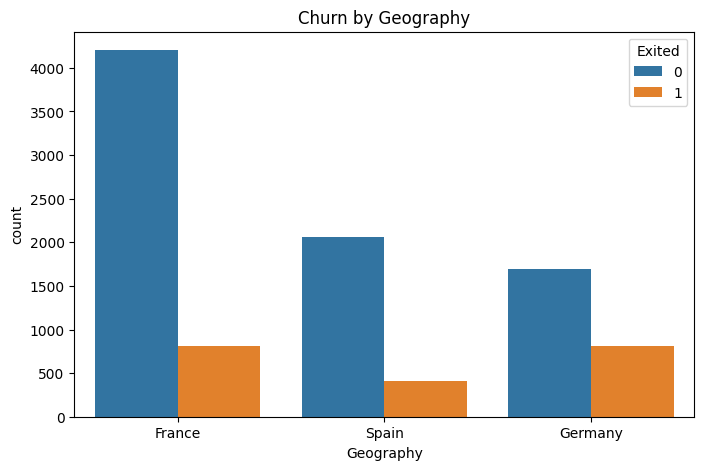

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.title("Churn by Geography")

plt.show()

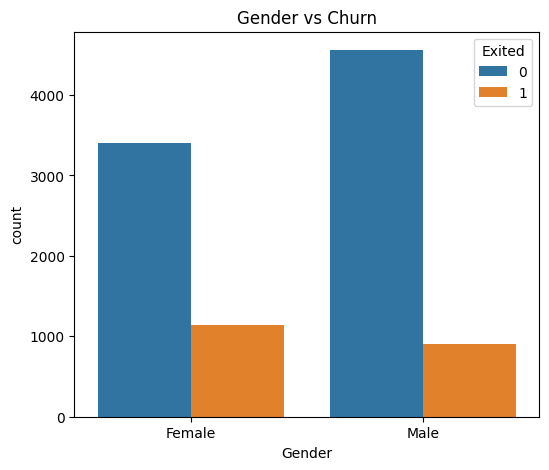

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Gender',
    hue='Exited',
    data=df
)

plt.title("Gender vs Churn")

plt.show()

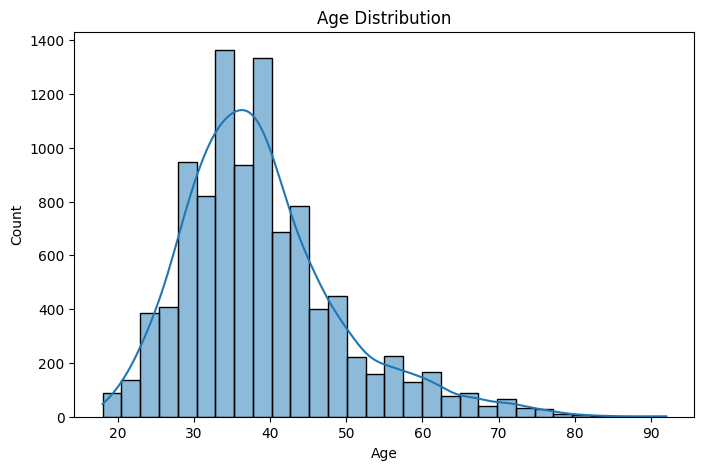

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

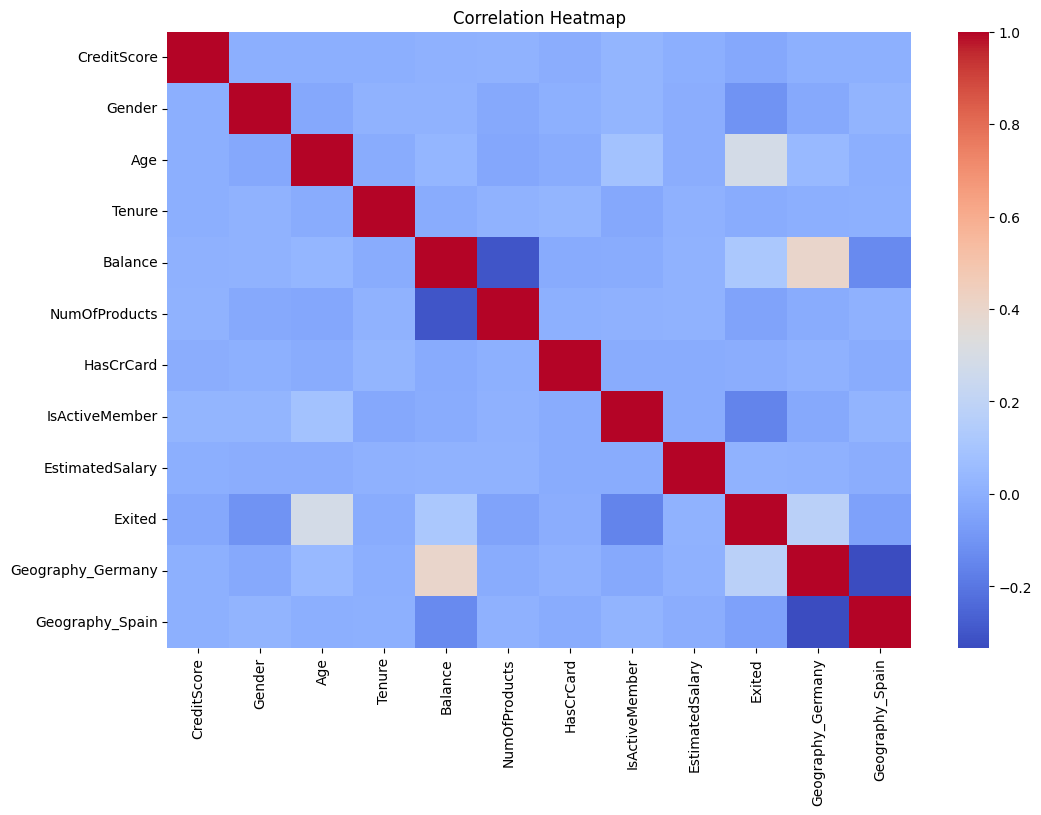

In [14]:
# Create a copy
temp = df.copy()

# Remove non-numeric columns
temp = temp.drop(['RowNumber','CustomerId','Surname'], axis=1)

# Encode Gender
temp['Gender'] = LabelEncoder().fit_transform(temp['Gender'])

# One-hot encode Geography
temp = pd.get_dummies(
    temp,
    columns=['Geography'],
    drop_first=True
)

# Correlation matrix
corr_matrix = temp.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

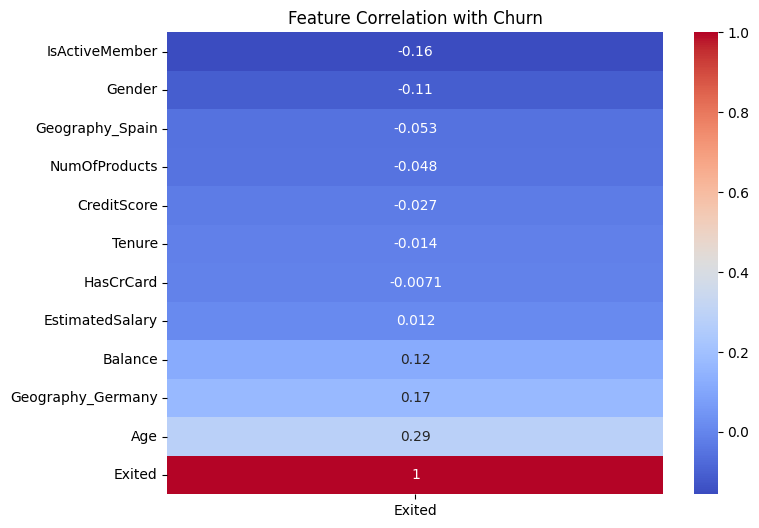

In [15]:
corr_with_target = temp.corr(numeric_only=True)['Exited'].sort_values()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_with_target.to_frame(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation with Churn")
plt.show()

In [16]:
df = df.drop(
    ['RowNumber',
     'CustomerId',
     'Surname'],
    axis=1
)

In [17]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(
    df['Gender']
)

In [18]:
df = pd.get_dummies(
    df,
    columns=['Geography'],
    drop_first=True
)

In [19]:
X = df.drop(
    'Exited',
    axis=1
)

y = df['Exited']

In [20]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred_lr
    )
)

0.811


In [23]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred_rf
    )
)

0.865


In [24]:
gb = GradientBoostingClassifier()

gb.fit(
    X_train,
    y_train
)

pred_gb = gb.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred_gb
    )
)

0.8675


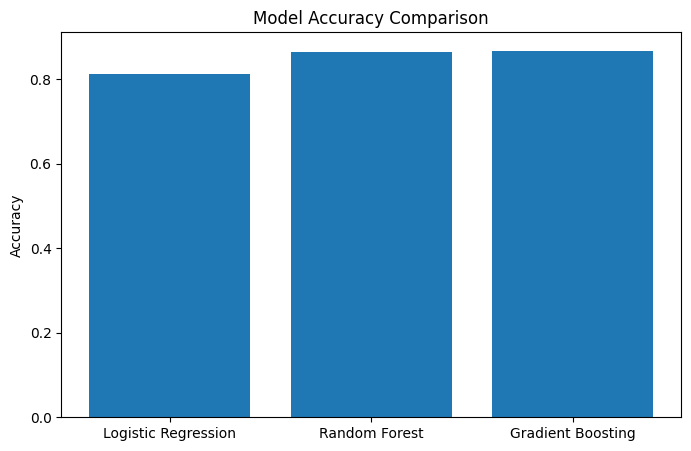

In [25]:
models = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting"
]

scores = [
    accuracy_score(y_test,pred_lr),
    accuracy_score(y_test,pred_rf),
    accuracy_score(y_test,pred_gb)
]

plt.figure(figsize=(8,5))

plt.bar(models,scores)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel("Accuracy")

plt.show()

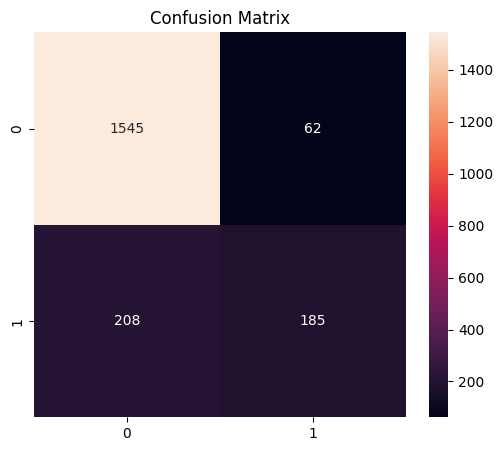

In [26]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

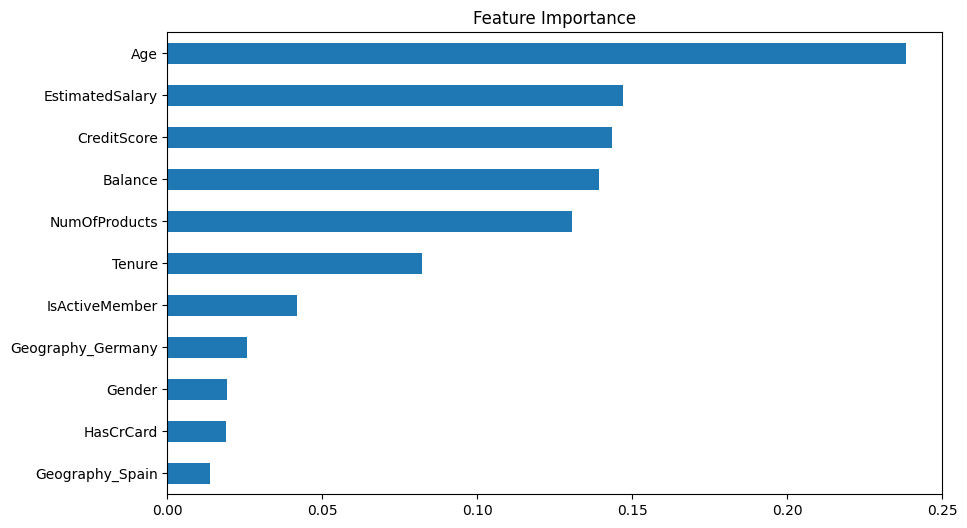

In [27]:
importance = pd.Series(
    rf.feature_importances_,
    index=df.drop(
        'Exited',
        axis=1
    ).columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title(
    "Feature Importance"
)

plt.show()